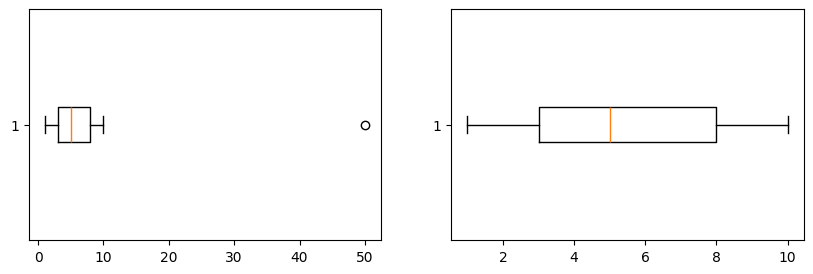

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Sample data with outliers (e.g., 50 is an extreme value)
data = [1, 2, 2, 3, 3, 4, 5, 6, 7, 8, 9, 10, 50]
df=pd.Series(data)
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.boxplot(data,vert=False)
plt.subplot(1,2,2)
plt.boxplot(data,vert=False,showfliers=False)

plt.show()


In [47]:
Q1= df.quantile(0.25)
Q3=df.quantile(0.75)
IQR=Q3-Q1
print(f"low Q1 ={Q1}")
print(f"high Q3 ={Q3}")
print(f"IQR ={IQR}")
LF=Q1-1.5*IQR
UF=Q3+1.5*IQR


low Q1 =3.0
high Q3 =8.0
IQR =5.0


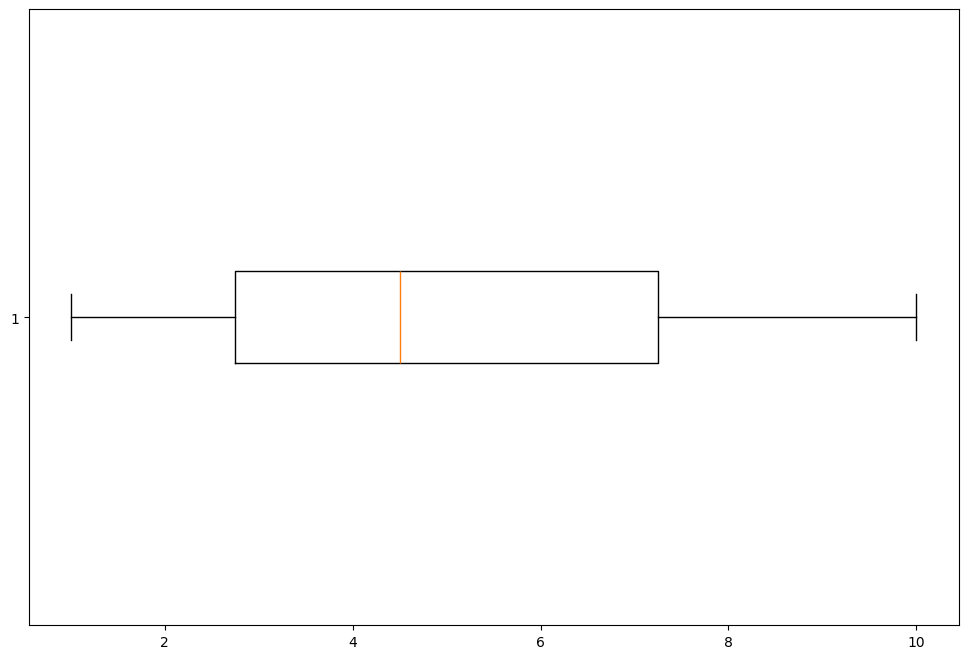

[1, 2, 2, 3, 3, 4, 5, 6, 7, 8, 9, 10, 50]

In [48]:
data_filter=df[(df >= LF) & (df <= UF)]
plt.figure(figsize=(12,8))
plt.boxplot(data_filter,vert=False)
plt.show()
df.tolist()

In [49]:
df=pd.read_csv("titanic.csv")
df.head()


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [50]:
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare'],
      dtype='object')

In [51]:
df.dtypes

Survived                     int64
Pclass                       int64
Name                        object
Sex                         object
Age                        float64
Siblings/Spouses Aboard      int64
Parents/Children Aboard      int64
Fare                       float64
dtype: object

In [52]:
df.shape

(887, 8)

In [53]:
df.describe

<bound method NDFrame.describe of      Survived  Pclass                                               Name  \
0           0       3                             Mr. Owen Harris Braund   
1           1       1  Mrs. John Bradley (Florence Briggs Thayer) Cum...   
2           1       3                              Miss. Laina Heikkinen   
3           1       1        Mrs. Jacques Heath (Lily May Peel) Futrelle   
4           0       3                            Mr. William Henry Allen   
..        ...     ...                                                ...   
882         0       2                               Rev. Juozas Montvila   
883         1       1                        Miss. Margaret Edith Graham   
884         0       3                     Miss. Catherine Helen Johnston   
885         1       1                               Mr. Karl Howell Behr   
886         0       3                                 Mr. Patrick Dooley   

        Sex   Age  Siblings/Spouses Aboard  Parents/C

In [54]:
df.isnull().sum()

Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.drop(columns="Name",inplace=True)
df

,Survived,Pclass,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
882,0,2,male,27.0,0,0,13.0000
883,1,1,female,19.0,0,0,30.0000
884,0,3,female,7.0,1,2,23.4500
885,1,1,male,26.0,0,0,30.0000


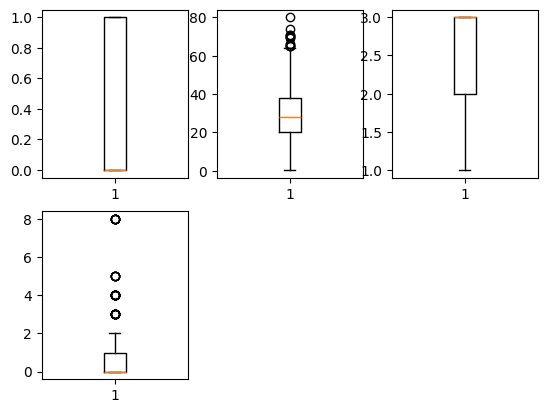

In [57]:
plt.subplot(2,3,1)
plt.boxplot(df["Survived"])
plt.subplot(2,3,2)
plt.boxplot(df["Age"])
plt.subplot(2,3,3)
plt.boxplot(df["Pclass"])
plt.subplot(2,3,4)
plt.boxplot(df["Siblings/Spouses Aboard"])
plt.show()

In [58]:
# df["Sex"]=np.where(df["Sex"]== "female","1","0")
df["Sex"] = df["Sex"].str.lower().map({"male":1,"female":0}).astype(int)
print(df.dtypes)
# df = pd.get_dummies(df, dtype= int)
df

Survived                     int64
Pclass                       int64
Sex                          int64
Age                        float64
Siblings/Spouses Aboard      int64
Parents/Children Aboard      int64
Fare                       float64
dtype: object


,Survived,Pclass,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,1,22.0,1,0,7.2500
1,1,1,0,38.0,1,0,71.2833
2,1,3,0,26.0,0,0,7.9250
3,1,1,0,35.0,1,0,53.1000
4,0,3,1,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
882,0,2,1,27.0,0,0,13.0000
883,1,1,0,19.0,0,0,30.0000
884,0,3,0,7.0,1,2,23.4500
885,1,1,1,26.0,0,0,30.0000


In [59]:
df.corr()


,Survived,Pclass,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
Survived,1.000000,-0.336528,-0.542152,-0.059665,-0.037082,0.080097,0.256179
Pclass,-0.336528,1.000000,0.129507,-0.391492,0.085026,0.020252,-0.548919
Sex,-0.542152,0.129507,1.000000,0.091875,-0.113249,-0.244337,-0.181137
Age,-0.059665,-0.391492,0.091875,1.000000,-0.297669,-0.193741,0.112329
Siblings/Spouses Aboard,-0.037082,0.085026,-0.113249,-0.297669,1.000000,0.414244,0.158839
Parents/Children Aboard,0.080097,0.020252,-0.244337,-0.193741,0.414244,1.000000,0.215470
Fare,0.256179,-0.548919,-0.181137,0.112329,0.158839,0.215470,1.000000


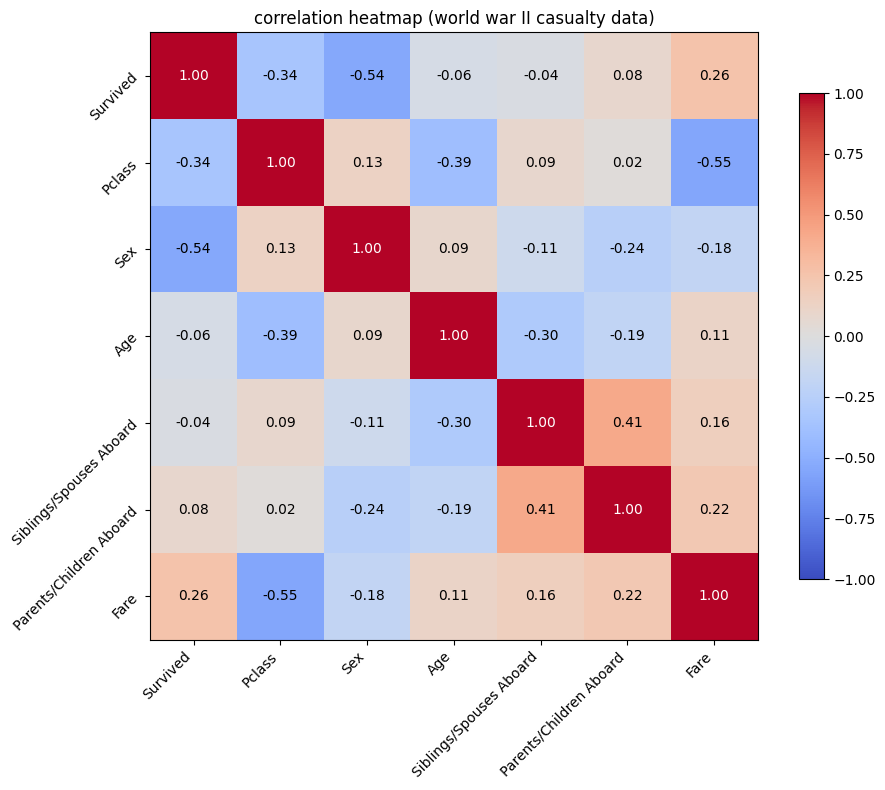

In [60]:
fig,ax=plt.subplots(figsize=(10,8))
cax=ax.imshow(df.corr(),cmap="coolwarm",vmin=-1,vmax=1)
ax.set_xticks(np.arange(len(df.corr().columns)))
ax.set_yticks(np.arange(len(df.corr().columns)))
ax.set_xticklabels(df.corr().columns,rotation=45,ha="right")
ax.set_yticklabels(df.corr().columns,rotation=45,ha="right")
fig.colorbar(cax,shrink=0.8)
for i in range(len(df.corr().columns)):
    for j in range(len(df.corr().columns)):
        text=ax.text(j,i,f"{df.corr().iloc[i,j]:.2f}" if not pd.isna(df.corr().iloc[i,j]) else "",
                                                                     ha="center", va="center",color="black" if abs(df.corr().iloc[i,j])<0.6 else "white")
plt.title("correlation heatmap (world war II casualty data)")
plt.tight_layout()
plt.show()

C:\Users\modernkade\AppData\Local\Temp\ipykernel_10524\1914150121.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


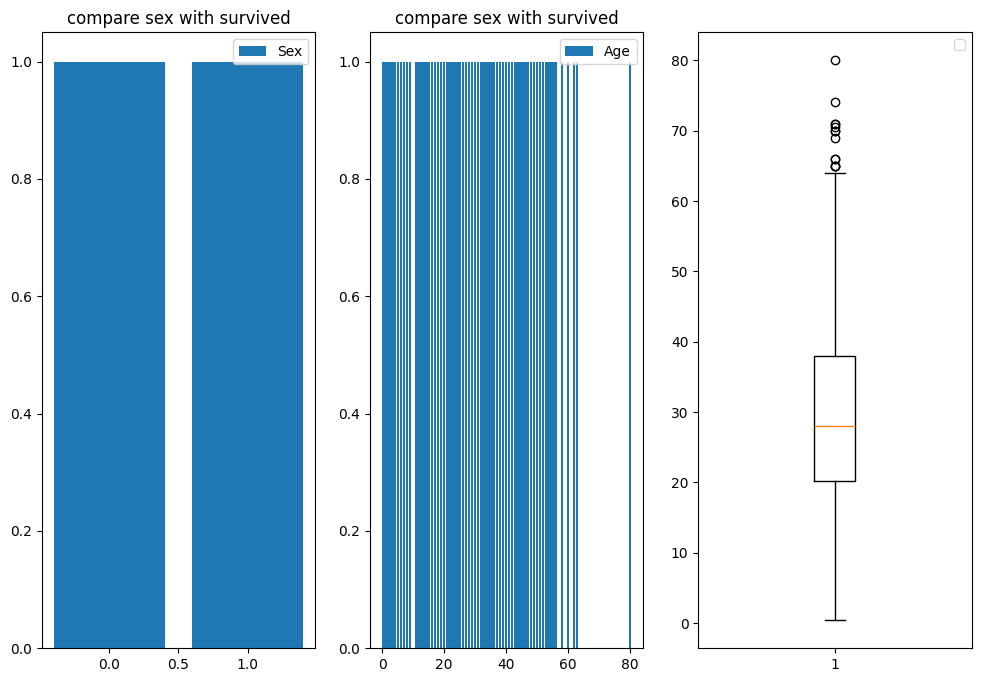

In [83]:
plt.figure(figsize=(12,8),dpi=100)
plt.subplot(1,3,1)
plt.bar(df["Sex"],df["Survived"],label="Sex")
plt.title("compare sex with survived")
plt.legend()
plt.subplot(1,3,2)
plt.bar(df["Age"],df["Survived"],label="Age")

plt.title("compare sex with survived")
plt.legend()
plt.subplot(1,3,3)
plt.boxplot(data=df, x=df["Age"])

plt.legend()
plt.show()

#### مسافران کلاس ۱ بیشتر زنده ماندند

1 Pclass
2 Sex
3 Age
4 Siblings/Spouses Aboard


C:\Users\modernkade\AppData\Local\Temp\ipykernel_10524\2817063095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived",y=col,data=df,palette="Set2")
C:\Users\modernkade\AppData\Local\Temp\ipykernel_10524\2817063095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived",y=col,data=df,palette="Set2")
C:\Users\modernkade\AppData\Local\Temp\ipykernel_10524\2817063095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived",y=col,data=df,palette="Set2")
C:\Users\modernkade\AppData\Local\Temp\ipykernel_10524\281706309

5 Parents/Children Aboard
6 Fare


C:\Users\modernkade\AppData\Local\Temp\ipykernel_10524\2817063095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived",y=col,data=df,palette="Set2")
C:\Users\modernkade\AppData\Local\Temp\ipykernel_10524\2817063095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived",y=col,data=df,palette="Set2")


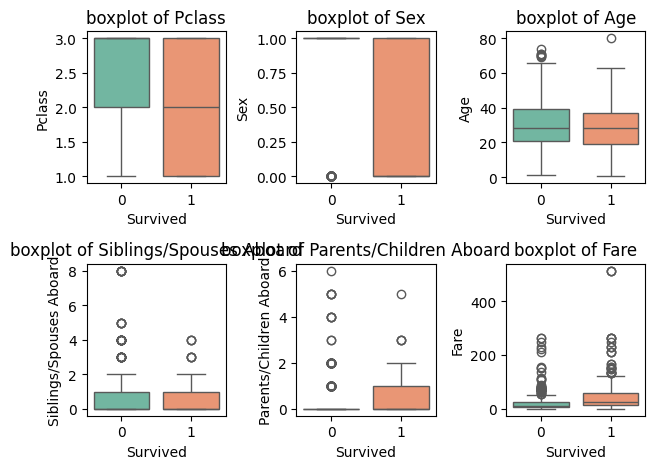

In [100]:
for i ,col in enumerate(df.columns[1:],1):
    print (i,col)
    plt.subplot(2,3,i)
    sns.boxplot(x="Survived",y=col,data=df,palette="Set2")
    plt.title(f"boxplot of {col}")
plt.tight_layout()
plt.show()

In [96]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare'],
      dtype='object')

#### سن در زنده ماندن نقش نسبی داشت

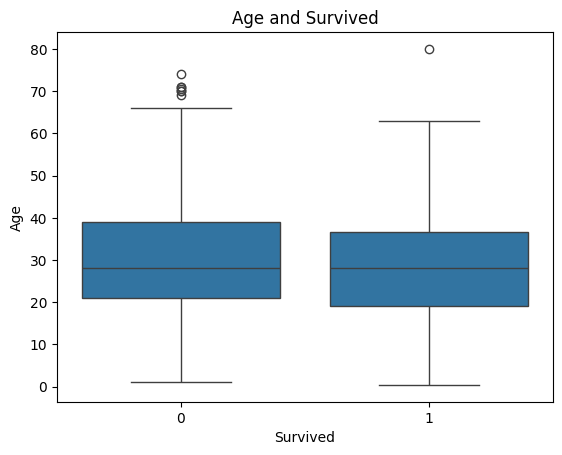

In [81]:
sns.boxplot(data=df,x = "Survived",y="Age")
plt.title("Age and Survived")
plt.show()

#### زنان بیشتر از مردان شانس زنده ماندن داشتند

<Axes: xlabel='Survived', ylabel='count'>

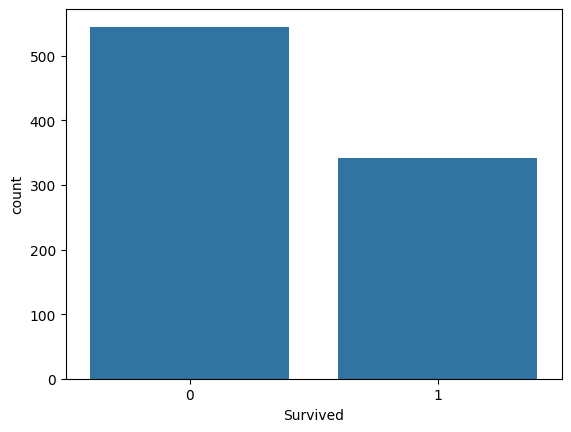

In [79]:
sns.countplot(data=df,x="Survived")

In [ ]:

# Separate the 'age' data by survival status
survived = df[df['survived'] == 1]['age']
not_survived = df[df['survived'] == 0]['age']

# Create the boxplot using matplotlib
plt.figure(figsize=(8, 6))
plt.boxplot([not_survived, survived], labels=['Not Survived', 'Survived'])

# Add axis labels and title
plt.xlabel('Survival Status')
plt.ylabel('Age')
plt.title('Age Distribution by Survival Status')

# Show the plot
plt.show()